In [ ]:
import numpy as np
import os
import sys
import pdb
from scipy.special import logsumexp


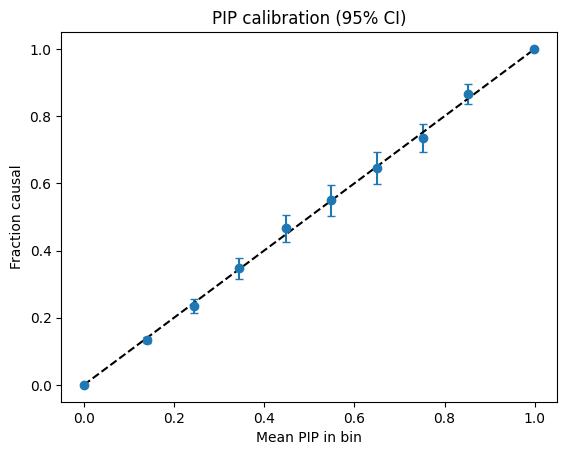

In [ ]:
################################################
# Single causal variant fine mapping simulation
################################################
import matplotlib.pyplot as plt

def single_causal_pips(beta, se, W=0.15**2):
    z = beta / se
    r = W / (se**2 + W)
    logbf = 0.5*np.log(1 - r) + 0.5*z**2*r
    return np.exp(logbf - logsumexp(logbf))



n_sims = 50000
n_vars = 500
sample_size = 5000
prior_var = 0.05

all_pips = []
all_causal = []
for sim_iter in range(n_sims):

    # Simulate causal effect sizes
    causal_effects = np.zeros(n_vars)
    causal_variant = np.random.randint(0, n_vars)
    causal_effects[causal_variant] = np.random.normal(0, scale=np.sqrt(prior_var))

    # Simulate estimated causal effect sizes with noise
    estimated_effects = causal_effects + np.random.normal(0, scale=np.sqrt(1.0/sample_size), size=n_vars)
    estimated_ses = np.sqrt(1.0/sample_size) * np.ones(n_vars)

    # Compute PIPs
    pips = single_causal_pips(estimated_effects, estimated_ses, W=prior_var)

    all_pips.append(pips)
    all_causal.append(causal_effects != 0)

all_pips = np.hstack(all_pips)
all_causal = np.hstack(all_causal)

# Calibration: bin by PIP, compare mean PIP to fraction causal (95% binomial CI)
bins = np.linspace(0, 1, 11)
bin_idx = np.digitize(all_pips, bins[1:-1])
xs, ys, errs = [], [], []
for b in range(len(bins) - 1):
    mask = bin_idx == b
    n = mask.sum()
    if n == 0:
        continue
    p = all_causal[mask].mean()
    xs.append(all_pips[mask].mean())
    ys.append(p)
    errs.append(1.96 * np.sqrt(p * (1 - p) / n))

plt.errorbar(xs, ys, yerr=errs, fmt='o', capsize=3)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Mean PIP in bin')
plt.ylabel('Fraction causal')
plt.title('PIP calibration (95% CI)')
plt.show()


scenario         true_sd  se_delta  se_exact  se_debias  cov_delta  cov_exact  cov_debias  frac_floor
strong/strong     0.1411    0.1418    0.1421     0.1414      0.948      0.948       0.947       0.000
strong/weak       0.1022    0.1025    0.1030     0.1020      0.953      0.954       0.952       0.000
null/strong       0.1008    0.1005    0.1010     0.1000      0.953      0.955       0.952       0.000
weak/weak         0.0298    0.0301    0.0319     0.0283      0.909      0.936       0.877       0.049
null/null         0.0100    0.0125    0.0166     0.0124      1.000      1.000       1.000       0.631


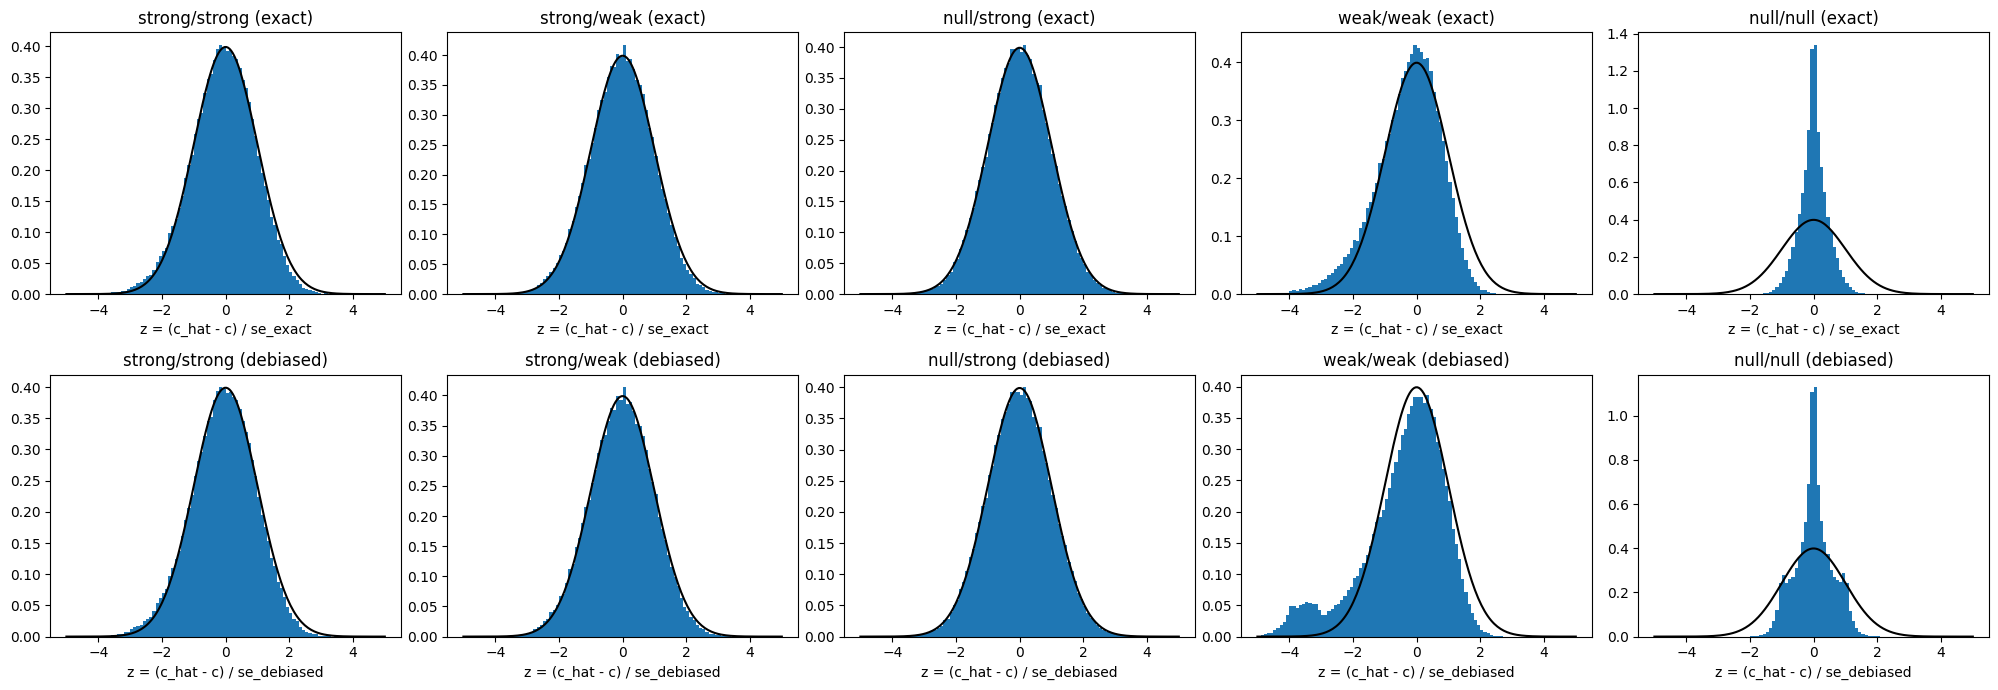

In [19]:
################################################
# Evaluate properties of standard errors of product of normal distributions
################################################
# a_hat ~ N(a, se_a^2), b_hat ~ N(b, se_b^2), independent. Estimate c = a*b by c_hat = a_hat*b_hat.
# Compare plug-in SEs (delta / exact / debiased) to the true sampling SD, and check coverage / z-score normality.
#   delta:    b_hat^2 se_a^2 + a_hat^2 se_b^2
#   exact:    delta + se_a^2 se_b^2            (E[var] = true_var + 2 se_a^2 se_b^2, biased up)
#   debiased: delta - se_a^2 se_b^2            (unbiased for true_var; floored at se_a^2 se_b^2, the minimum possible true variance)

def product_se(a_hat, b_hat, se_a, se_b, mode='exact'):
    var = (b_hat**2)*(se_a**2) + (a_hat**2)*(se_b**2)
    if mode == 'exact':
        var = var + (se_a**2)*(se_b**2)
    elif mode == 'debiased':
        var = np.maximum(var - (se_a**2)*(se_b**2), (se_a**2)*(se_b**2))
    return np.sqrt(var)

n_sims = 100000
# (a, b, se_a, se_b)
scenarios = [
    ('strong/strong', 1.0, 1.0, 0.1, 0.1),
    ('strong/weak',   1.0, 0.2, 0.1, 0.1),
    ('null/strong',   0.0, 1.0, 0.1, 0.1),
    ('weak/weak',     0.2, 0.2, 0.1, 0.1),
    ('null/null',     0.0, 0.0, 0.1, 0.1),
]
modes = ['exact', 'debiased']

fig, axes = plt.subplots(len(modes), len(scenarios), figsize=(4*len(scenarios), 3.5*len(modes)))
print(f"{'scenario':15s} {'true_sd':>8s} {'se_delta':>9s} {'se_exact':>9s} {'se_debias':>10s} {'cov_delta':>10s} {'cov_exact':>10s} {'cov_debias':>11s} {'frac_floor':>11s}")
grid = np.linspace(-5, 5, 200)
for j, (name, a, b, se_a, se_b) in enumerate(scenarios):
    a_hat = np.random.normal(a, se_a, n_sims)
    b_hat = np.random.normal(b, se_b, n_sims)
    c_hat = a_hat * b_hat
    c = a * b

    true_sd = np.std(c_hat)
    ses = {m: product_se(a_hat, b_hat, se_a, se_b, mode=m) for m in ['delta', 'exact', 'debiased']}
    covs = {m: np.mean(np.abs(c_hat - c) < 1.96*ses[m]) for m in ses}
    raw_debias_var = (b_hat**2)*(se_a**2) + (a_hat**2)*(se_b**2) - (se_a**2)*(se_b**2)
    frac_floor = np.mean(raw_debias_var < (se_a**2)*(se_b**2))
    print(f"{name:15s} {true_sd:8.4f} {np.mean(ses['delta']):9.4f} {np.mean(ses['exact']):9.4f} {np.mean(ses['debiased']):10.4f} "
          f"{covs['delta']:10.3f} {covs['exact']:10.3f} {covs['debiased']:11.3f} {frac_floor:11.3f}")

    # z-scores vs standard normal, one row per SE estimator
    for i, m in enumerate(modes):
        ax = axes[i, j]
        z = (c_hat - c) / ses[m]
        ax.hist(z, bins=100, density=True, range=(-5, 5))
        ax.plot(grid, np.exp(-grid**2/2)/np.sqrt(2*np.pi), 'k-')
        ax.set_title(f'{name} ({m})')
        ax.set_xlabel(f'z = (c_hat - c) / se_{m}')
plt.tight_layout()
plt.show()


scenario         true_sd  se_exact    mc_sd  cov_normal  cov_mc_pct  ci_width_normal  ci_width_mc
strong/strong     0.1413    0.1422   0.1422       0.947       0.949           0.5574       0.5565
strong/weak       0.1033    0.1030   0.1030       0.953       0.949           0.4039       0.4049
null/strong       0.1006    0.1010   0.1010       0.956       0.950           0.3961       0.3975
weak/weak         0.0299    0.0320   0.0320       0.939       0.949           0.1254       0.1259
null/null         0.0102    0.0166   0.0166       1.000       0.998           0.0650       0.0694


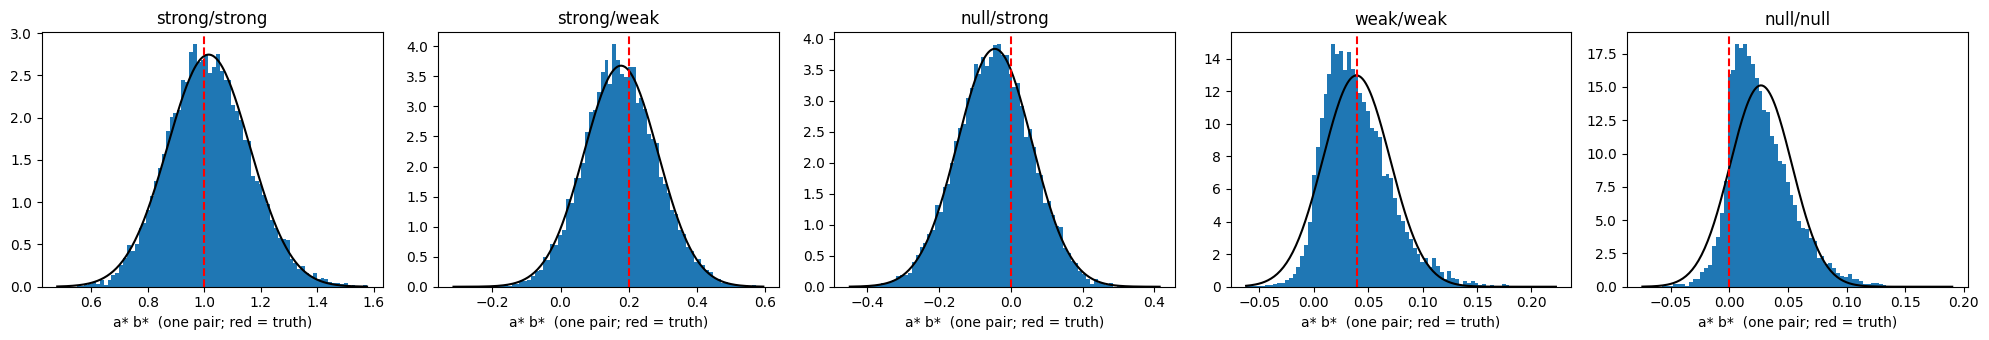

In [21]:
################################################
# Parametric Monte Carlo around the estimates (Preacher & Selig style)
################################################
# For each simulated pair: draw a* ~ N(a_hat, se_a), b* ~ N(b_hat, se_b), form a*b*.
# MC SD should reproduce the exact plug-in SE; MC percentile CI captures skew of the product.

n_sims = 20000
n_mc = 10000
scenarios = [
    ('strong/strong', 1.0, 1.0, 0.1, 0.1),
    ('strong/weak',   1.0, 0.2, 0.1, 0.1),
    ('null/strong',   0.0, 1.0, 0.1, 0.1),
    ('weak/weak',     0.2, 0.2, 0.1, 0.1),
    ('null/null',     0.0, 0.0, 0.1, 0.1),
]

print(f"{'scenario':15s} {'true_sd':>8s} {'se_exact':>9s} {'mc_sd':>8s} {'cov_normal':>11s} {'cov_mc_pct':>11s} {'ci_width_normal':>16s} {'ci_width_mc':>12s}")
fig, axes = plt.subplots(1, len(scenarios), figsize=(4*len(scenarios), 3.5))
for ax, (name, a, b, se_a, se_b) in zip(axes, scenarios):
    a_hat = np.random.normal(a, se_a, n_sims)
    b_hat = np.random.normal(b, se_b, n_sims)
    c_hat = a_hat * b_hat
    c = a * b

    # Monte Carlo draws around each pair's estimates: shape (n_sims, n_mc)
    a_star = a_hat[:, None] + se_a * np.random.normal(size=(n_sims, n_mc))
    b_star = b_hat[:, None] + se_b * np.random.normal(size=(n_sims, n_mc))
    c_star = a_star * b_star

    mc_sd = np.std(c_star, axis=1)
    mc_lo = np.percentile(c_star, 2.5, axis=1)
    mc_hi = np.percentile(c_star, 97.5, axis=1)

    se_exact = product_se(a_hat, b_hat, se_a, se_b, mode='exact')
    lo_norm = c_hat - 1.96*se_exact
    hi_norm = c_hat + 1.96*se_exact

    cov_normal = np.mean((lo_norm < c) & (c < hi_norm))
    cov_mc = np.mean((mc_lo < c) & (c < mc_hi))
    print(f"{name:15s} {np.std(c_hat):8.4f} {np.mean(se_exact):9.4f} {np.mean(mc_sd):8.4f} {cov_normal:11.3f} {cov_mc:11.3f} "
          f"{np.mean(hi_norm - lo_norm):16.4f} {np.mean(mc_hi - mc_lo):12.4f}")

    # MC distribution for one representative pair vs its normal approximation
    k = 0
    ax.hist(c_star[k], bins=80, density=True)
    grid = np.linspace(c_star[k].min(), c_star[k].max(), 200)
    ax.plot(grid, np.exp(-(grid - c_hat[k])**2/(2*se_exact[k]**2))/(se_exact[k]*np.sqrt(2*np.pi)), 'k-')
    ax.axvline(c, color='r', linestyle='--')
    ax.set_title(name)
    ax.set_xlabel('a* b*  (one pair; red = truth)')
plt.tight_layout()
plt.show()
